In [319]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [320]:
def f(x):
    return 5*x**2-9*x+20

In [321]:
f(2.0)

22.0

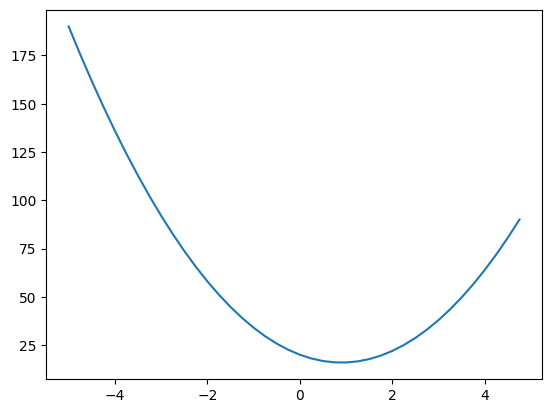

In [322]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

How to get f(x)'s derivative?
1. By formula, yet explict function is needed. 
2. By definition, we change a little on x, to see how much the f(x) changes. 

In [323]:
h = 0.00001 # a small positive step
x = -3.0
(f(x+h)-f(x))/h

-38.99995000153922

In [324]:
# more complex: multiple input values
a = 2.0
b = -3.0
c = 10.0
d = a*b + c # d=f(a,b,c)=a*b+c
d

4.0

In [325]:
h = 0.000001

a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
c += h
d2 = a*b + c

(d2-d1)/h # partial derivative of d respect to a

0.9999999992515995

In [326]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        # printable representation (differ from 'readable' format)
        return f'Value(data={self.data})'

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    __radd__ = __add__
    
    def __neg__(self):
        return self * (-1)
    def __sub__(self, other):
        return self + (-other)
    def __rsub__(self, other):
        return self - other
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other, label=f'{other}')
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other,(self, ), f'**{other}' )
        def _backward():
            if other != 0:
                self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * (other ** -1)

    def tanh(self):
        out = Value(float(np.tanh(self.data)), (self,), 'tanh')
        def _backward():
            self.grad += (1 - out.data**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # topological sort
        topo = []
        visited = set()
        def build_topo(v): # postorder traversal
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        self.grad = 1.0
        build_topo(self)
        topo.reverse()
        for n in topo:
            n._backward()

a = Value(2.0, label='a')
b = Value(4.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e + c; d.label='d'
f = Value(-1.0, label='f')
L = d * f; L.label='L'
L

Value(data=-18.0)

$$
\frac{\partial}{\partial x}(xy)=y
$$
$$
\frac{\partial}{\partial x}(x+y)=1
$$
$$
\frac{\partial z}{\partial x} = \frac{\partial z}{\partial y} \frac{\partial y}{\partial x}
$$

In [327]:
L.grad = 1.0
f.grad = d.data
d.grad = f.data
e.grad = d.grad * 1
c.grad = d.grad * 1
b.grad = e.grad * a.data
a.grad = e.grad * b.data

In [328]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, simple=False):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        if not simple:
            dot.node(name=uid, label='{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
            if n._op:
                dot.node(name=uid+n._op, label=n._op, shape='diamond')
                dot.edge(uid+n._op, uid)
        else:
            dot.node(name=uid, label='{ %.2f | %.2f }' % (n.data,n.grad), shape='record')
        

    for n1, n2 in edges:
        if not simple:
            dot.edge(str(id(n1)), str(id(n2))+n2._op)
        else:
            dot.edge(str(id(n1)), str(id(n2)))
    return dot


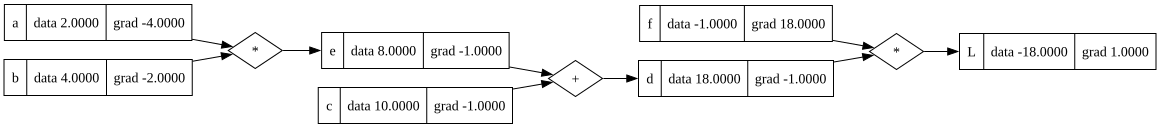

In [329]:
draw_dot(L)

In [330]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print(L.data)

-14.588456000000003


In [331]:
def lol():
    h = 0.00001

    a = Value(2.0, label='a')
    b = Value(4.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-1.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data


    a = Value(2.0, label='a')
    b = Value(4.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-1.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data + h
    print((L2-L1)/h)
lol()

0.9999999999621422


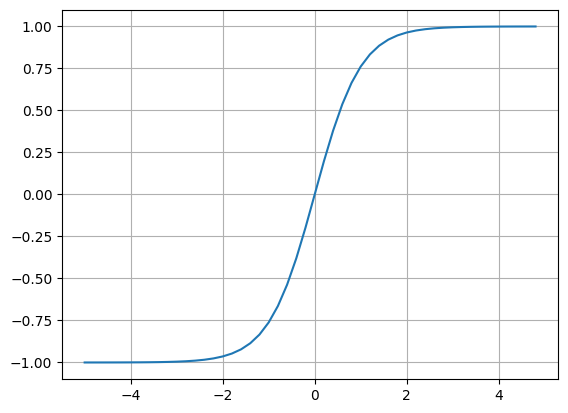

In [332]:
# activation function
xs = np.arange(-5,5, 0.2)
ys = np.tanh(xs)
plt.plot(xs, ys)
plt.grid()

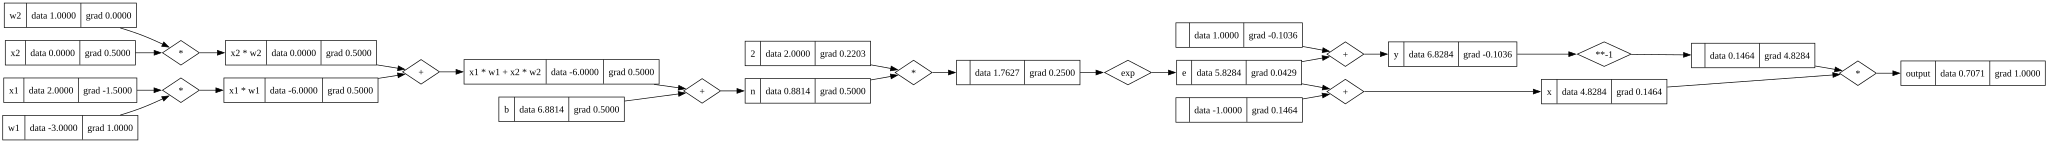

In [333]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b') # make output=1/sqrt(2)
x1w1 = x1*w1; x1w1.label='x1 * w1'
x2w2 = x2*w2; x2w2.label='x2 * w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1 * w1 + x2 * w2'
n = x1w1x2w2 + b; n.label='n'
# o = n.tanh(); o.label = 'output'
# break up tanh
e = (2*n).exp(); e.label = 'e'
x = e - 1; x.label = 'x'
y = e + 1; y.label = 'y'
o = x / y; o.label = 'output'
o.backward()
draw_dot(o)

$$
\frac{\text{d}}{\text{d}x}\tanh x=1-\tanh^2 x 
$$

Topological Sort
<img src='asset/topo.webp' />

In [334]:
# topological sort
topo = []
visited = set()
def build_topo(v): # postorder traversal
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

o.grad = 1.0
build_topo(o)
topo.reverse()
for n in topo:
    n._backward()

In [335]:
# backward manually
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
w1._backward()
x2._backward()
w2._backward()




In [336]:
# backward explicitly
o.grad = 1
n.grad = (1 - o.data**2) * o.grad

b.grad = n.grad * 1  # infact, just n.grad
x1w1x2w2.grad = n.grad * 1  # infact, just n.grad
x1w1.grad = x1w1x2w2.grad * 1  # infact, just n.grad
x2w2.grad = x1w1x2w2.grad * 1  # infact, just n.grad

w1.grad = x1w1.grad * x1.data
w2.grad = x2w2.grad * x2.data
x1.grad = x1w1.grad * w1.data
x2.grad = x2w2.grad * w2.data


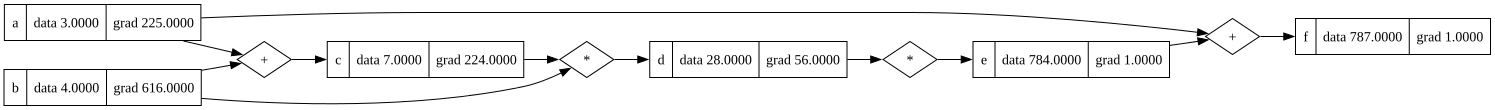

In [337]:
a = Value(3.0, label='a')
b = Value(4.0, label='b')
c = a + b; c.label = 'c'
d = b * c; d.label = 'd'
e = d * d; e.label = 'e'
f = a + e; f.label = 'f'

f.backward()
draw_dot(f)

using pytorch

In [338]:
import torch

t = torch.Tensor([[1,2,3],[4,5,6]])
t.shape

torch.Size([2, 3])

In [339]:

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


Neural Network
<img src='asset/deepneuralnetwork.png'/>

In [340]:
import random
random.seed(42)

class Neuron:
    def __init__(self, nin):
        # nin: number of inputs
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum(list(wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
# multilayer perceptron
class MLP:
    def __init__(self, nin:int, nouts:list):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    


In [ ]:
x = [2.0, 3.0, 4.0]


In [342]:
len(n.parameters())

41

In [355]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]
n = MLP(3, [4,4,1])

Mean Square Error
$$
L = \frac{1}{n}\sum^n_{i=1}(y_{i}-\hat{y}_{i})^2
$$
Gradient Descent
$$
\vec{p} = \vec{p} - \alpha \nabla L(\vec{p})
$$

In [373]:
learning_rate = 0.05


for k in range(1, 101):
    # forward prop
    ypred = [n(x) for x in xs] 
    loss = sum(((ygt-yout[0])**2 for ygt, yout in zip(ys, ypred))) / len(ys)

    for p in n.parameters():
        p.grad = 0 # important!!!!

    # back prop
    loss.backward()

    # update
    for p in n.parameters():
        p.data -= learning_rate * p.grad
        p.grad = 0 # important!!!!
    if k % 10 == 0:
        print(f'k={k}, loss={loss.data}')
    

k=10, loss=0.00048297979553745034
k=20, loss=0.00047990001425957134
k=30, loss=0.0004768581154552054
k=40, loss=0.0004738534131610865
k=50, loss=0.0004708852377614325
k=60, loss=0.0004679529355060162
k=70, loss=0.00046505586804510576
k=80, loss=0.0004621934119806545
k=90, loss=0.00045936495843300644
k=100, loss=0.00045656991262256567
